In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier


In [11]:
kz = pd.read_csv('kase.csv'); us = pd.read_csv('us.csv')
kz['date']=pd.to_datetime(kz['date']); us['date']=pd.to_datetime(us['date'])
kz = kz.sort_values(['ticker','date']).reset_index(drop=True)
us = us.sort_values(['ticker','date']).reset_index(drop=True)
print(f'KZ: {kz.shape}, {kz.date.min().date()} -> {kz.date.max().date()}')
print(f'US: {us.shape}, {us.date.min().date()} -> {us.date.max().date()}')


KZ: (27252, 35), 2019-03-15 -> 2026-03-20
US: (84277, 50), 2021-06-30 -> 2026-03-23


In [12]:
def create_target(df, t=0.05):
    def label(x):
        if pd.isna(x): return np.nan
        if x >  t: return 'buy'
        if x < -t: return 'sell'
        return 'hold'
    df['target'] = df['ret_fwd_20'].apply(label); return df

kz = create_target(kz); us = create_target(us)
print('KZ:'); print(kz['target'].value_counts(dropna=False))
print('US:'); print(us['target'].value_counts(dropna=False))


KZ:
target
hold    17305
buy      5610
sell     4337
Name: count, dtype: int64
US:
target
hold    40346
buy     24923
sell    19008
Name: count, dtype: int64


In [13]:
drop_cols = ['ticker', 'date', 'ret_fwd_20', 'label', 'threshold'] 

# Технические признаки 
tech_features = ['open', 'high', 'low', 'close', 'adj_close', 'volume',
                 'ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'sma_20', 'sma_50',
                 'ema_12', 'ema_26', 'price_to_sma50', 'rsi_14', 'macd', 
                 'macd_signal', 'macd_hist', 'stoch_k', 'bb_upper', 'bb_lower',
                 'bb_width', 'atr_14', 'volume_ratio_20', 'volume_roc', 'obv',
                 'overnight_gap', 'intraday_range', 'sigma_20d']

# Фундаментальные признаки (только для US)
fund_features = ['eps', 'revenue', 'revenue_growth_yoy', 'gross_margin', 
                 'operating_margin', 'net_margin', 'roe', 'debt_to_equity',
                 'current_ratio', 'fcf', 'operating_cf', 'pe_ttm', 'pb', 
                 'ps_ttm', 'days_since_report']

# Создаем копии данных
kz_tech = kz[tech_features + ['target']].copy()
us_tech = us[tech_features + ['target']].copy()
us_fund = us[fund_features + ['target']].copy()

print(f"   KZ (технические): {kz_tech.shape[0]} строк, {kz_tech.shape[1]} колонок")
print(f"   US (технические): {us_tech.shape[0]} строк, {us_tech.shape[1]} колонок")
print(f"   US (фундамент):   {us_fund.shape[0]} строк, {us_fund.shape[1]} колонок")

   KZ (технические): 27252 строк, 31 колонок
   US (технические): 84277 строк, 31 колонок
   US (фундамент):   84277 строк, 16 колонок


In [14]:
def prepare_train_test(train_df, test_df, features):
    train_df = train_df.dropna(subset=["target"]).reset_index(drop=True)
    test_df  = test_df.dropna(subset=["target"]).reset_index(drop=True)
    le = LabelEncoder().fit(["buy","hold","sell"])
    y_tr = le.transform(train_df["target"]); y_te = le.transform(test_df["target"])
    Xtr = train_df[features].copy(); Xte = test_df[features].copy()
    imp = SimpleImputer(strategy="median", keep_empty_features=True).fit(Xtr)
    Xtr = pd.DataFrame(imp.transform(Xtr), columns=features)
    Xte = pd.DataFrame(imp.transform(Xte), columns=features)
    sc  = StandardScaler().fit(Xtr)
    Xtr = pd.DataFrame(sc.transform(Xtr), columns=features)
    Xte = pd.DataFrame(sc.transform(Xte), columns=features)
    return Xtr, Xte, y_tr, y_te, le


In [15]:
split_date = pd.Timestamp('2025-01-01')
kz_tr_df = kz[kz.date <  split_date]; kz_te_df = kz[kz.date >= split_date]
us_tr_df = us[us.date <  split_date]; us_te_df = us[us.date >= split_date]

Xk_train, Xk_test, yk_train, yk_test, le_kz = prepare_train_test(kz_tr_df, kz_te_df, tech_features)
Xu_tech_train, Xu_tech_test, yu_tech_train, yu_tech_test, _ = prepare_train_test(us_tr_df, us_te_df, tech_features)
Xu_fund_train, Xu_fund_test, yu_fund_train, yu_fund_test, _ = prepare_train_test(us_tr_df, us_te_df, fund_features)

print(f'KZ:      train={len(Xk_train)}, test={len(Xk_test)}')
print(f'US tech: train={len(Xu_tech_train)}, test={len(Xu_tech_test)}')
print(f'US fund: train={len(Xu_fund_train)}, test={len(Xu_fund_test)}')


KZ:      train=20717, test=6535
US tech: train=62622, test=21655
US fund: train=62622, test=21655


In [16]:
def make_model():
    return XGBClassifier(objective='multi:softprob', num_class=3,
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, eval_metric='mlogloss', tree_method='hist')

def train_and_evaluate(model, Xtr, ytr, Xte, yte, name):
    model.fit(Xtr, ytr); yp = model.predict(Xte)
    acc = accuracy_score(yte, yp)
    print(f'\n{name}\n  Accuracy: {acc:.4f}')
    present = sorted(set(yte) | set(yp)); names_all = ['buy','hold','sell']
    print(classification_report(yte, yp, labels=present,
          target_names=[names_all[i] for i in present], zero_division=0))
    return model, acc

model_kz, acc_kz = train_and_evaluate(make_model(), Xk_train, yk_train, Xk_test, yk_test, 'KZ stocks (technical)')
model_us_tech, acc_us_tech = train_and_evaluate(make_model(), Xu_tech_train, yu_tech_train, Xu_tech_test, yu_tech_test, 'US stocks (technical)')
model_us_fund, acc_us_fund = train_and_evaluate(make_model(), Xu_fund_train, yu_fund_train, Xu_fund_test, yu_fund_test, 'US stocks (fundamental)')



KZ stocks (technical)
  Accuracy: 0.5752
              precision    recall  f1-score   support

         buy       0.27      0.13      0.17      1391
        hold       0.63      0.88      0.73      3925
        sell       0.33      0.10      0.16      1219

    accuracy                           0.58      6535
   macro avg       0.41      0.37      0.35      6535
weighted avg       0.50      0.58      0.51      6535


US stocks (technical)
  Accuracy: 0.4165
              precision    recall  f1-score   support

         buy       0.33      0.24      0.27      6715
        hold       0.46      0.71      0.56      9849
        sell       0.26      0.08      0.13      5091

    accuracy                           0.42     21655
   macro avg       0.35      0.34      0.32     21655
weighted avg       0.37      0.42      0.37     21655


US stocks (fundamental)
  Accuracy: 0.3438
              precision    recall  f1-score   support

         buy       0.31      0.10      0.15      6715
 

In [17]:
print(f"\n{'Модель':<40} {'Accuracy':<10}")
print(f"{'KZ (технические)':<40} {acc_kz:.4f}")
print(f"{'US (технические)':<40} {acc_us_tech:.4f}")
print(f"{'US (фундаментальные)':<40} {acc_us_fund:.4f}")

best_model = max([
    ("KZ", acc_kz),
    ("US тех", acc_us_tech),
    ("US фунд", acc_us_fund)
], key=lambda x: x[1])

print(f"\n Лучшая модель: {best_model[0]} с accuracy = {best_model[1]:.4f}")


Модель                                   Accuracy  
KZ (технические)                         0.5752
US (технические)                         0.4165
US (фундаментальные)                     0.3438

 Лучшая модель: KZ с accuracy = 0.5752


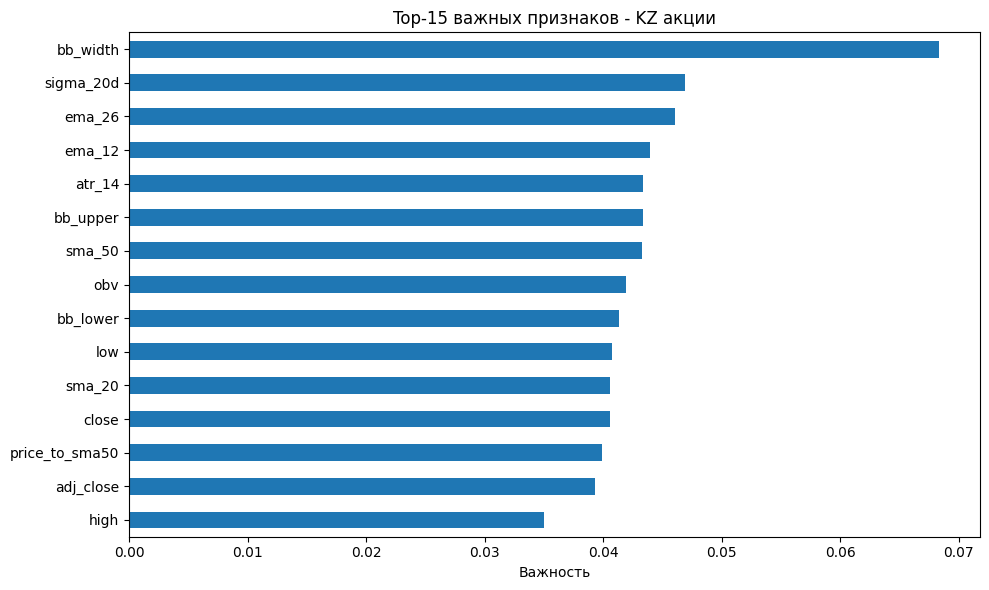

In [18]:
def plot_feature_importance(model, feature_names, title):
    importance = pd.Series(model.feature_importances_, index=feature_names)
    importance = importance.sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    importance.plot(kind='barh')
    plt.xlabel('Важность')
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

if best_model[0] == "KZ":
    plot_feature_importance(model_kz, Xk_train.columns, 
                           "Top-15 важных признаков - KZ акции")
elif best_model[0] == "US тех":
    plot_feature_importance(model_us_tech, Xu_tech_train.columns, 
                           "Top-15 важных признаков - US акции (технические)")
else:
    plot_feature_importance(model_us_fund, Xu_fund_train.columns, 
                           "Top-15 важных признаков - US акции (фундаментальные)")


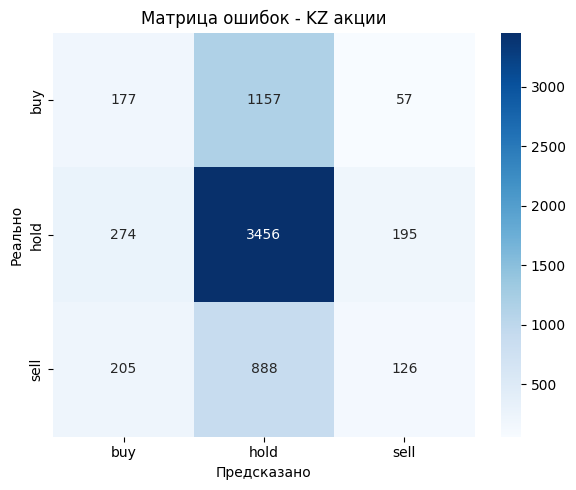

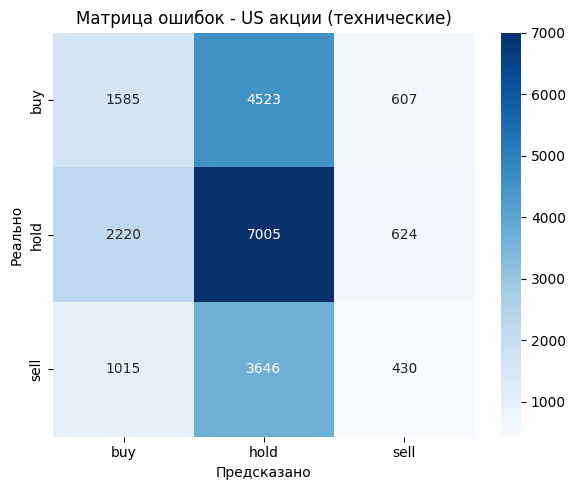

In [19]:
def plot_confusion_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['buy', 'hold', 'sell'],
                yticklabels=['buy', 'hold', 'sell'])
    plt.xlabel('Предсказано')
    plt.ylabel('Реально')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(model_kz, Xk_test, yk_test, 
                     "Матрица ошибок - KZ акции")
plot_confusion_matrix(model_us_tech, Xu_tech_test, yu_tech_test, 
                     "Матрица ошибок - US акции (технические)")

In [20]:
def walk_forward_cv(X, y, name, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = cross_val_score(make_model(), X, y, cv=tscv, scoring='accuracy', n_jobs=1)
    print(f'{name}: mean={scores.mean():.4f} (+/- {scores.std():.4f}) folds={[f"{s:.4f}" for s in scores]}')
    return scores

print('WALK-FORWARD CV (TimeSeriesSplit, train portion only)')
walk_forward_cv(Xk_train, yk_train, 'KZ (technical)')
walk_forward_cv(Xu_tech_train, yu_tech_train, 'US (technical)')


WALK-FORWARD CV (TimeSeriesSplit, train portion only)
KZ (technical): mean=0.5523 (+/- 0.0904) folds=['0.6840', '0.4186', '0.5183', '0.5264', '0.6141']
US (technical): mean=0.4478 (+/- 0.0421) folds=['0.3719', '0.4733', '0.4827', '0.4320', '0.4793']


array([0.37194596, 0.47331609, 0.48270576, 0.4320207 , 0.47925649])